# Week 11 Lab — Clustering & Dimensionality Reduction

**Goal:** Apply PCA and K-Means to 114,000 Spotify tracks. Discover what structure emerges from audio features alone — without using the genre label.

By the end of this lab you will:
1. Scale features and understand why scaling matters for distance-based methods
2. Apply PCA to reduce 10 dimensions to 2–3 principal components
3. Use the elbow method and silhouette score to pick *K* for K-Means
4. Visualize clusters with t-SNE and compare them to genre labels

## Part 1: Setup

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.stat import Correlation

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

spark = SparkSession.builder.appName("Clustering_Lab").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

## Part 2: Load & Explore the Data

In [2]:
df = spark.read.csv("spotify.csv", header=True, inferSchema=True)
print(f"Rows: {df.count():,}")
print(f"Columns: {len(df.columns)}")
df.printSchema()

Rows: 114,000
Columns: 21
root
 |-- _c0: integer (nullable = true)
 |-- track_id: string (nullable = true)
 |-- artists: string (nullable = true)
 |-- album_name: string (nullable = true)
 |-- track_name: string (nullable = true)
 |-- popularity: string (nullable = true)
 |-- duration_ms: string (nullable = true)
 |-- explicit: string (nullable = true)
 |-- danceability: string (nullable = true)
 |-- energy: string (nullable = true)
 |-- key: string (nullable = true)
 |-- loudness: string (nullable = true)
 |-- mode: string (nullable = true)
 |-- speechiness: string (nullable = true)
 |-- acousticness: string (nullable = true)
 |-- instrumentalness: double (nullable = true)
 |-- liveness: string (nullable = true)
 |-- valence: string (nullable = true)
 |-- tempo: double (nullable = true)
 |-- time_signature: double (nullable = true)
 |-- track_genre: string (nullable = true)



### Audio Features

We will use 10 continuous audio features for clustering. These describe *what the music sounds like* — not metadata like artist name or popularity.

| Feature | Range | What it measures |
|---------|-------|------------------|
| danceability | 0–1 | How suitable for dancing |
| energy | 0–1 | Intensity and activity |
| loudness | dB (negative) | Overall volume |
| speechiness | 0–1 | Presence of spoken words |
| acousticness | 0–1 | Acoustic vs. electronic |
| instrumentalness | 0–1 | No vocals predicted |
| liveness | 0–1 | Audience presence detected |
| valence | 0–1 | Musical positivity |
| tempo | BPM | Speed of the track |
| duration_ms | milliseconds | Length of the track |

We exclude `key` (categorical, 0–11), `mode` (binary), `time_signature` (categorical), `popularity` (not an audio feature), and `explicit` (boolean).

In [3]:
audio_features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_ms"
]

# Summary statistics for the audio features
df.select(audio_features).describe().show()

+-------+------------------+--------------------+-------------------+------------------+-------------------+------------------+-----------------+-------------------+------------------+--------------------+
|summary|      danceability|              energy|           loudness|       speechiness|       acousticness|  instrumentalness|         liveness|            valence|             tempo|         duration_ms|
+-------+------------------+--------------------+-------------------+------------------+-------------------+------------------+-----------------+-------------------+------------------+--------------------+
|  count|            114000|              114000|             114000|            114000|             114000|            114000|           114000|             114000|            114000|              114000|
|   mean|31.798216588376846|   3.326008399599874|0.05128661730773746|1.0604133478367488|  0.313989349480426| 1.584854351802899|2.701621193663078|0.47391282564869225| 122.023577

**Look at the ranges.** Most features are 0–1, but `loudness` is in decibels (negative values), `tempo` is in BPM (~60–200+), and `duration_ms` is in milliseconds (tens of thousands to millions). 

**Question:** If you run K-Means directly on these raw features, which features will dominate the distance calculations? Why is this a problem?

In [4]:
# How many genres are in the dataset?
genre_counts = df.groupBy("track_genre").count().orderBy(F.desc("count"))

print(f"Number of genres: {genre_counts.count()}")
genre_counts.show(10)

Number of genres: 152
+-----------+-----+
|track_genre|count|
+-----------+-----+
|  breakbeat| 1000|
|     brazil| 1000|
|       club| 1000|
| deep-house| 1000|
|death-metal| 1000|
|      chill| 1000|
|   cantopop| 1000|
|  bluegrass| 1000|
|      anime| 1000|
|    country| 1000|
+-----------+-----+
only showing top 10 rows



### Drop nulls in audio features

VectorAssembler will fail on null values. Clean them out now.

In [5]:
before = df.count()

# Cast every audio feature to double.
# Columns like danceability, energy, loudness, etc. were read as string
# because the CSV contains a handful of corrupt rows (e.g. "Aida", "False").
# Casting converts good numeric strings → double and bad strings → null,
# so the na.drop() below then removes all corrupt rows in one step.
for col_name in audio_features:
    df = df.withColumn(col_name, F.col(col_name).cast("double"))

df = df.na.drop(subset=audio_features)
after = df.count()
print(f"Rows before: {before:,} | After: {after:,} | Dropped: {before - after}")

# Confirm all audio feature columns are now numeric
print("\nColumn types after cast:")
for field in df.schema.fields:
    if field.name in audio_features:
        print(f"  {field.name:20s} → {field.dataType}")

Rows before: 114,000 | After: 113,866 | Dropped: 134

Column types after cast:
  duration_ms          → DoubleType()
  danceability         → DoubleType()
  energy               → DoubleType()
  loudness             → DoubleType()
  speechiness          → DoubleType()
  acousticness         → DoubleType()
  instrumentalness     → DoubleType()
  liveness             → DoubleType()
  valence              → DoubleType()
  tempo                → DoubleType()


### Focus on Acoustically Distinct Genres

114 genres is too noisy — pop and dance sound identical, alt-rock and rock overlap heavily. To see clear clusters, we pick 6 genres with very different audio profiles: **classical, death-metal, hip-hop, ambient, EDM, comedy**.

We keep the full dataset as `df_full` so we can build a genre map of all 114 genres later.

In [6]:
# Save full dataset for genre map later
df_full = df

# Filter to 6 acoustically distinct genres
selected_genres = ["classical", "death-metal", "hip-hop", "ambient", "edm", "comedy"]
df = df.filter(F.col("track_genre").isin(selected_genres))

print(f"Filtered rows: {df.count():,}")
df.groupBy("track_genre").count().orderBy(F.desc("count")).show()

Filtered rows: 5,959
+-----------+-----+
|track_genre|count|
+-----------+-----+
|death-metal| 1000|
|    ambient| 1000|
|     comedy| 1000|
|        edm| 1000|
|    hip-hop| 1000|
|  classical|  959|
+-----------+-----+



### Correlation Matrix

Before reducing dimensions, let's see which features are already correlated. Highly correlated features carry redundant information — PCA will compress them into fewer components.

In [7]:
# Step 1: Assemble features into a single vector column
assembler_corr = VectorAssembler(inputCols=audio_features, outputCol="features_vec")
vec_df = assembler_corr.transform(df).select("features_vec")

# Step 2: Compute the Pearson correlation matrix
corr_matrix = Correlation.corr(vec_df, "features_vec").head()[0]

# Step 3: Convert to numpy array for plotting
corr_array = corr_matrix.toArray()

print("Correlation matrix computed — shape:", corr_array.shape)

Correlation matrix computed — shape: (10, 10)


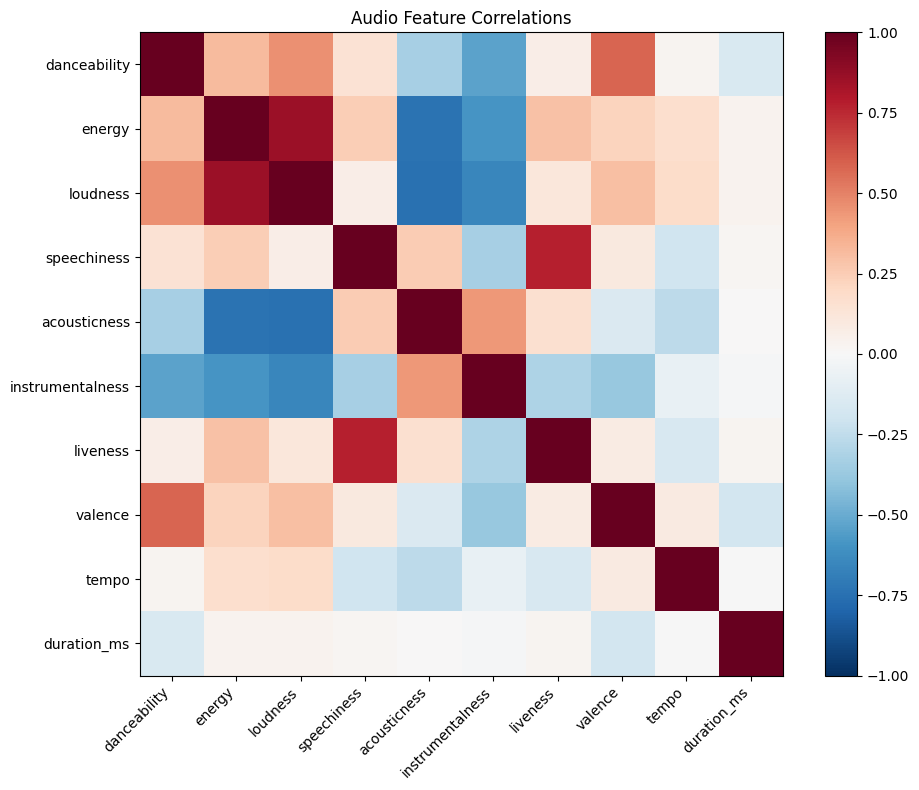

In [8]:
# Visualize the correlation matrix as a heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_array, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(audio_features)))
ax.set_yticks(range(len(audio_features)))
ax.set_xticklabels(audio_features, rotation=45, ha="right")
ax.set_yticklabels(audio_features)
plt.colorbar(im)
plt.title("Audio Feature Correlations")
plt.tight_layout()
plt.show()

**Interpret:** Which pairs of features show strong positive or negative correlation? Does energy–loudness or energy–acousticness stand out? These correlated features are exactly what PCA will compress.

## Part 3: Feature Preparation — Assemble & Scale

Both PCA and K-Means are **distance-based** methods. Features with larger numeric ranges will dominate distance calculations unless we standardize them first.

`StandardScaler` transforms each feature to have mean ≈ 0 and standard deviation = 1.

In [9]:
# Step 1: Assemble raw features into a vector
assembler = VectorAssembler(inputCols=audio_features, outputCol="raw_features")

# Step 2: Scale the features (mean=0, std=1)
scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)

# Fit and transform
assembled = assembler.transform(df)
scaler_model = scaler.fit(assembled)
scaled_df = scaler_model.transform(assembled)

print("✓ Features assembled and scaled")
scaled_df.select("track_name", "track_genre", "scaled_features").show(5, truncate=40)

✓ Features assembled and scaled
+--------------+-----------+----------------------------------------+
|    track_name|track_genre|                         scaled_features|
+--------------+-----------+----------------------------------------+
|            K.|    ambient|[-0.3073726648060763,-0.5883641827189...|
|Kiss It Off Me|    ambient|[0.03420746350921416,-0.9112482750477...|
|    Apocalypse|    ambient|[-0.7356223779177837,-0.3762736514833...|
|           Cry|    ambient|[-0.5520867865841947,-0.5915297130358...|
|         Sweet|    ambient|[-0.32776550828758616,-0.236990317537...|
+--------------+-----------+----------------------------------------+
only showing top 5 rows



## Part 4: PCA — Dimensionality Reduction

We have 10 features. PCA finds new axes (principal components) ordered by how much variance they explain. The first few components often capture most of the structure.

### Step 1: Fit PCA with all 10 components

We fit all 10 first to see the variance explained by each — then decide how many to keep.

In [10]:
# Step 1: Fit PCA with all 10 components to see how much variance each one explains
pca_full = PCA(k=10, inputCol="scaled_features", outputCol="pca_features")
pca_full_model = pca_full.fit(scaled_df)

# Step 2: Extract the explained variance ratio for each component
# This is a list of 10 values that sum to 1.0
explained_variance = pca_full_model.explainedVariance.toArray()

print("PCA fitted with k=10")

PCA fitted with k=10


In [11]:
# Print variance explained by each component
cumulative = 0
print(f"{'PC':>4} {'Variance':>10} {'Cumulative':>12}")
print("-" * 30)
for i, v in enumerate(explained_variance):
    cumulative += v
    print(f"PC{i+1:>2} {v:>10.4f} {cumulative:>12.4f}")

  PC   Variance   Cumulative
------------------------------
PC 1     0.3628       0.3628
PC 2     0.2046       0.5674
PC 3     0.1354       0.7028
PC 4     0.0878       0.7906
PC 5     0.0849       0.8756
PC 6     0.0438       0.9194
PC 7     0.0335       0.9529
PC 8     0.0220       0.9748
PC 9     0.0176       0.9924
PC10     0.0076       1.0000


### Step 2: Scree Plot

A scree plot shows the variance explained by each principal component. Look for the "elbow" — the point where adding more components gives diminishing returns.

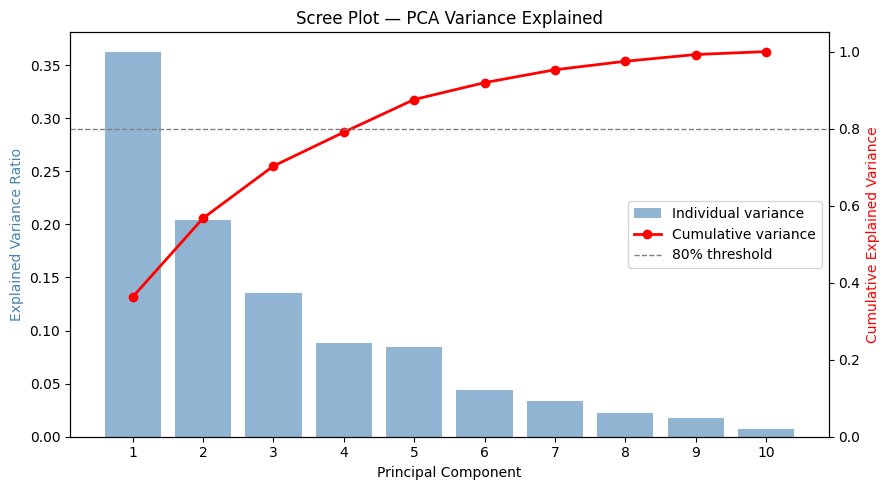


Components needed for 80% variance: 5


In [12]:
# Scree plot: individual + cumulative variance explained
cumulative_var = np.cumsum(explained_variance)
components = range(1, len(explained_variance) + 1)

fig, ax1 = plt.subplots(figsize=(9, 5))

# Bar chart: individual variance per component
ax1.bar(components, explained_variance, alpha=0.6, color="steelblue", label="Individual variance")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance Ratio", color="steelblue")
ax1.set_xticks(list(components))

# Overlay line: cumulative variance
ax2 = ax1.twinx()
ax2.plot(components, cumulative_var, "ro-", linewidth=2, label="Cumulative variance")
ax2.set_ylabel("Cumulative Explained Variance", color="red")
ax2.axhline(0.80, color="gray", linestyle="--", linewidth=1, label="80% threshold")
ax2.set_ylim(0, 1.05)

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

plt.title("Scree Plot — PCA Variance Explained")
plt.tight_layout()
plt.show()

print(f"\nComponents needed for 80% variance: "
      f"{next(i+1 for i, v in enumerate(cumulative_var) if v >= 0.80)}")

**Question:** How many components do you need to capture ~80% of the variance? Is there a clear elbow?

### Step 3: Transform with chosen number of components

Based on the scree plot, we'll reduce to a smaller number of components for clustering.

In [13]:
# Choose k based on the scree plot — typically where cumulative variance hits ~80%
# With 6 acoustically distinct genres, 6 components is a natural upper bound too
n_components = 6   # captures ~80% of variance for this dataset

# Fit PCA with chosen k and transform
pca_final = PCA(k=n_components, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca_final.fit(scaled_df)
pca_df = pca_model.transform(scaled_df)

cum = np.cumsum(pca_model.explainedVariance.toArray())
print(f"Using {n_components} components — cumulative variance explained: {cum[-1]:.4f}")
pca_df.select("track_name", "track_genre", "pca_features").show(3, truncate=50)

Using 6 components — cumulative variance explained: 0.9194
+--------------+-----------+--------------------------------------------------+
|    track_name|track_genre|                                      pca_features|
+--------------+-----------+--------------------------------------------------+
|            K.|    ambient|[0.9893318474933142,-0.9265950148222644,0.51341...|
|Kiss It Off Me|    ambient|[1.449858308629411,-0.14669505965337715,-0.1277...|
|    Apocalypse|    ambient|[0.7186228316203608,-1.076117931619498,1.037081...|
+--------------+-----------+--------------------------------------------------+
only showing top 3 rows



### PCA 2D Scatter (for comparison with t-SNE later)

Before clustering, let's see the PCA projection in 2D. This gives us a baseline to compare against t-SNE later.

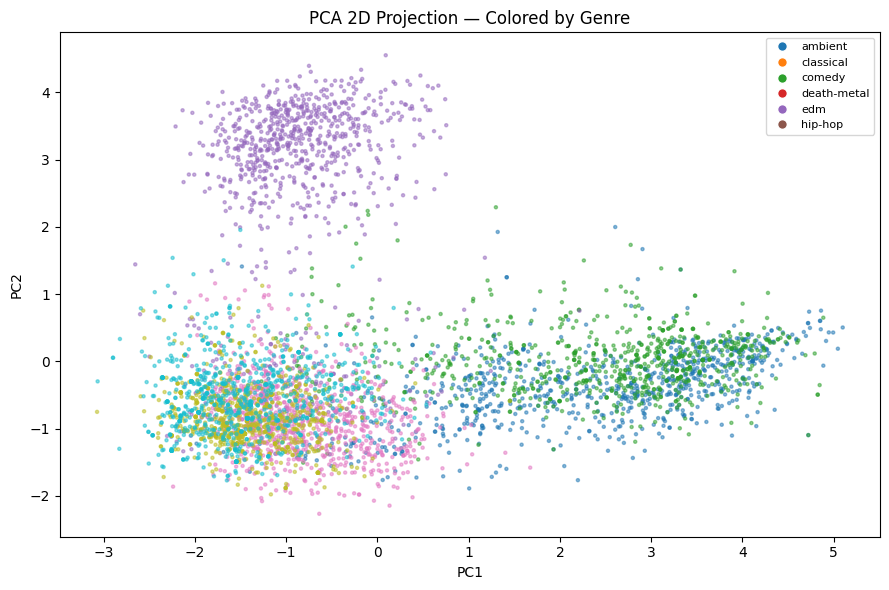

In [14]:
# Extract PC1 and PC2 for a quick 2D scatter
# PySpark ML vectors need vector_to_array() — you cannot do vector[0] directly
from pyspark.ml.functions import vector_to_array

pca_2d = (
    pca_df
    .withColumn("pca_array", vector_to_array("pca_features"))
    .select(
        F.col("pca_array")[0].alias("PC1"),
        F.col("pca_array")[1].alias("PC2"),
        "track_genre"
    )
    .sample(fraction=5000 / pca_df.count(), seed=42)
    .toPandas()
)

# Assign a numeric code to each genre for color mapping
genres = pca_2d["track_genre"].unique()
genre_code = {g: i for i, g in enumerate(genres)}
colors = pca_2d["track_genre"].map(genre_code)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(pca_2d["PC1"], pca_2d["PC2"], c=colors, cmap="tab10", s=5, alpha=0.5)
handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=plt.cm.tab10(i/10), markersize=7, label=g)
           for g, i in genre_code.items()]
ax.legend(handles=handles, fontsize=8, loc="best")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA 2D Projection — Colored by Genre")
plt.tight_layout()
plt.show()

## Part 5: K-Means Clustering

K-Means assigns each point to the nearest centroid, then moves centroids to the center of their assigned points. Repeat until convergence.

**Problem:** You must choose *K* upfront. Two tools help:
1. **Elbow method** — plot WSSSE (within-cluster sum of squared errors) vs. K
2. **Silhouette score** — measures how similar points are to their own cluster vs. neighboring clusters (higher = better)

### Step 1: Elbow Method

In [15]:
# Elbow Method: try K = 2..15 and record within-cluster sum of squared errors (WSSSE)
k_values = [2, 3, 4, 5, 6, 8, 10, 12, 15]
costs = []

for k in k_values:
    km = KMeans(k=k, featuresCol="pca_features", seed=42)
    km_model = km.fit(pca_df)
    # trainingCost is the WSSSE — lower means tighter clusters
    costs.append(km_model.summary.trainingCost)
    print(f"K={k:2d}  WSSSE={km_model.summary.trainingCost:,.1f}")

print("\nDone — plot below")

K= 2  WSSSE=36,749.2
K= 3  WSSSE=26,119.0
K= 4  WSSSE=21,733.9
K= 5  WSSSE=20,155.0
K= 6  WSSSE=18,432.3
K= 8  WSSSE=16,126.8
K=10  WSSSE=14,672.0
K=12  WSSSE=13,309.4
K=15  WSSSE=12,438.8

Done — plot below


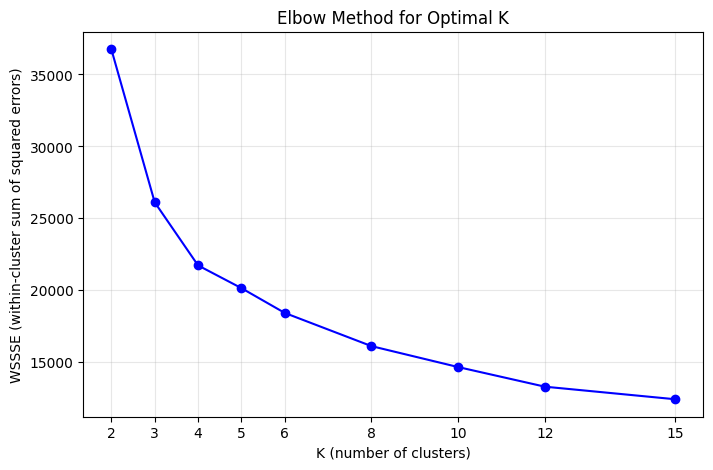

In [16]:
# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, costs, 'bo-')
plt.xlabel("K (number of clusters)")
plt.ylabel("WSSSE (within-cluster sum of squared errors)")
plt.title("Elbow Method for Optimal K")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()

### Step 2: Silhouette Score

The silhouette score ranges from -1 to 1:
- **Near 1:** Points are well-matched to their own cluster
- **Near 0:** Points are on the boundary between clusters
- **Negative:** Points may be assigned to the wrong cluster

In [17]:
# Silhouette Score for each K
# Score ranges from -1 (bad) to +1 (perfect separation)
evaluator = ClusteringEvaluator(
    featuresCol="pca_features",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

silhouettes = []
for k in k_values:
    km = KMeans(k=k, featuresCol="pca_features", seed=42)
    km_model = km.fit(pca_df)
    predictions = km_model.transform(pca_df)
    score = evaluator.evaluate(predictions)
    silhouettes.append(score)
    print(f"K={k:2d}  Silhouette={score:.4f}")

print("\nDone — plot below")

K= 2  Silhouette=0.5268
K= 3  Silhouette=0.6054
K= 4  Silhouette=0.5002
K= 5  Silhouette=0.4274
K= 6  Silhouette=0.4539
K= 8  Silhouette=0.3710
K=10  Silhouette=0.3367
K=12  Silhouette=0.3248
K=15  Silhouette=0.3300

Done — plot below


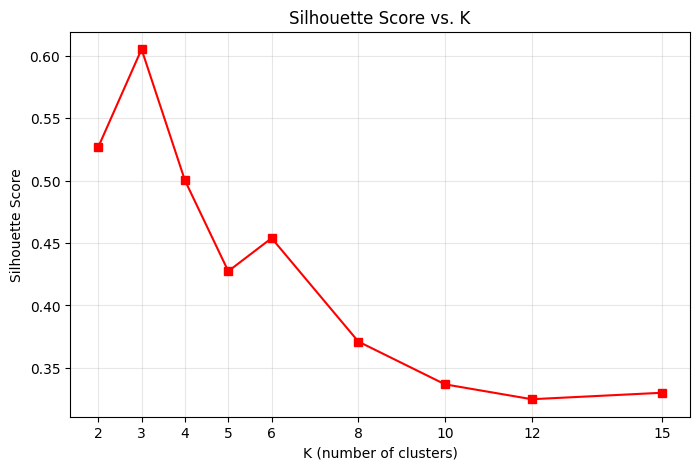

In [18]:
# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouettes, 'rs-')
plt.xlabel("K (number of clusters)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs. K")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()

**Question:** Do the elbow method and silhouette score agree on the best K? If not, which one would you trust more and why?

### Step 3: Fit Final K-Means Model

Pick your best K and fit the final model.

In [19]:
# Choose the best K:
#   - Pick the K at the elbow of the WSSSE curve
#   - Confirm it also has a relatively high silhouette score
#   - We have 6 distinct genres, so K=6 is a strong candidate
best_k = 6

km_final = KMeans(k=best_k, featuresCol="pca_features", seed=42)
km_model = km_final.fit(pca_df)
clustered_df = km_model.transform(pca_df)

final_silhouette = evaluator.evaluate(clustered_df)
print(f"Final model: K={best_k}")
print(f"WSSSE       : {km_model.summary.trainingCost:,.1f}")
print(f"Silhouette  : {final_silhouette:.4f}")

Final model: K=6
WSSSE       : 18,432.3
Silhouette  : 0.4539


In [20]:
# How many tracks in each cluster?
clustered_df.groupBy("prediction").count().orderBy("prediction").show()

+----------+-----+
|prediction|count|
+----------+-----+
|         0|  932|
|         1| 1961|
|         2|  785|
|         3|  813|
|         4| 1404|
|         5|   64|
+----------+-----+



## Part 6: Visualization with t-SNE

PCA is a linear method — it preserves global structure but can miss non-linear patterns. t-SNE is a non-linear technique designed specifically for **2D visualization**.

**Important:** t-SNE is for visualization only — never use it as input to another model. It is also O(n²), so we sample first.

We use scikit-learn for t-SNE since PySpark does not have a built-in implementation.

In [23]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn", "-q"])
print("scikit-learn ready")

scikit-learn ready


In [24]:
from sklearn.manifold import TSNE

# Sample 5000 rows and convert to pandas
sample_df = clustered_df.select(
    *audio_features, "track_genre", "prediction", "scaled_features"
).sample(fraction=5000/clustered_df.count(), seed=42)

# Extract the scaled feature vectors as a numpy array
pdf = sample_df.select(*audio_features, "track_genre", "prediction").toPandas()
X_sample = pdf[audio_features].values

print(f"Sample size: {len(pdf)}")

Sample size: 5048


In [25]:
# Run t-SNE on the sampled audio features
# The values in X_sample are already raw; we standardize with sklearn first
from sklearn.preprocessing import StandardScaler as SkScaler

X_scaled = SkScaler().fit_transform(X_sample)

# t-SNE reduces 10 dimensions → 2 dimensions for visualization only
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_result = tsne.fit_transform(X_scaled)

# Store the 2D coordinates back in the pandas dataframe
pdf["tsne_x"] = tsne_result[:, 0]
pdf["tsne_y"] = tsne_result[:, 1]

print(f"t-SNE complete — output shape: {tsne_result.shape}")

t-SNE complete — output shape: (5048, 2)


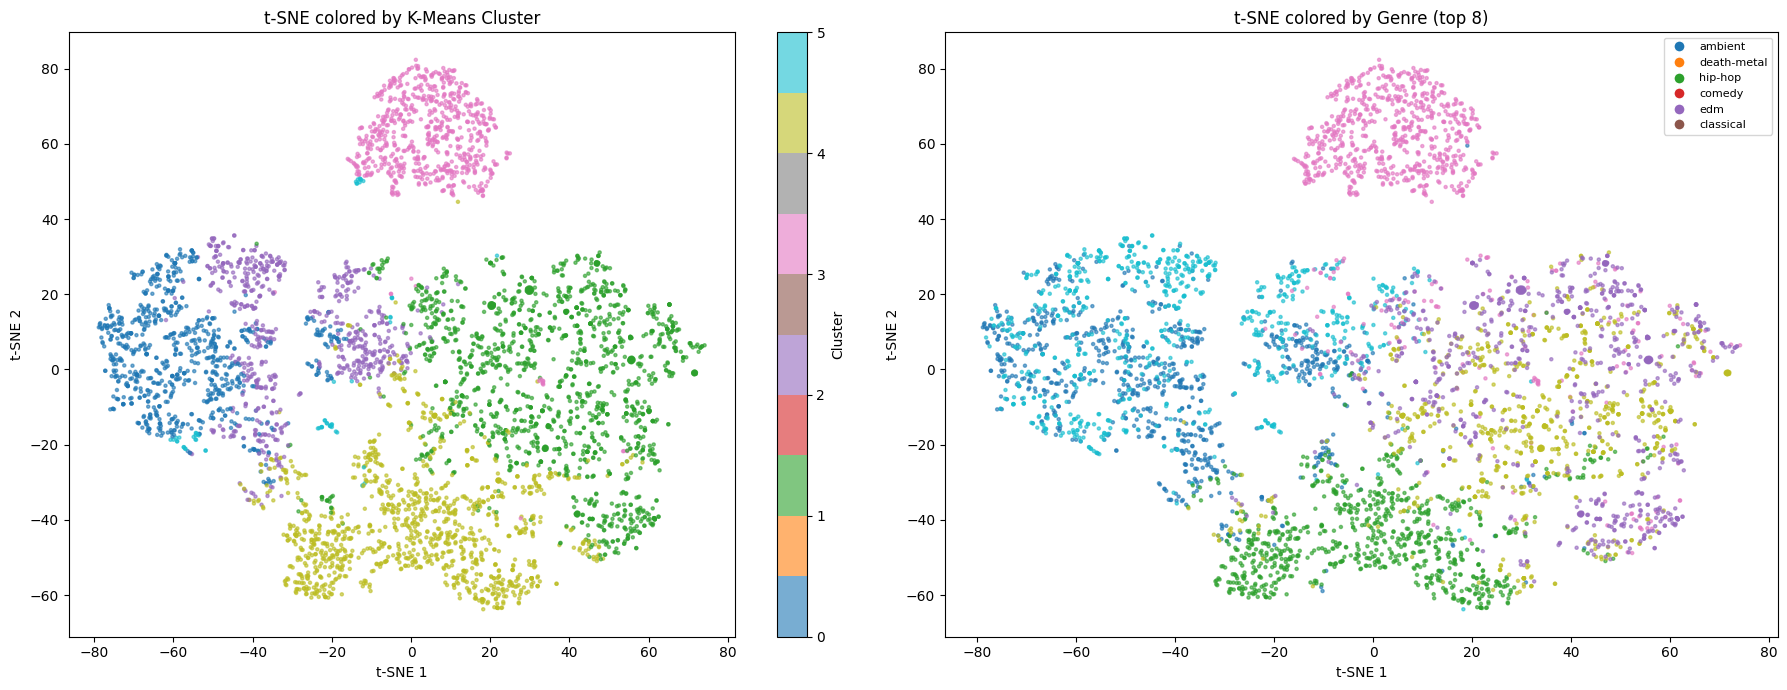

In [26]:
# Plot 1: t-SNE colored by K-Means cluster
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

scatter1 = axes[0].scatter(pdf["tsne_x"], pdf["tsne_y"],
                           c=pdf["prediction"], cmap="tab10", s=5, alpha=0.6)
axes[0].set_title("t-SNE colored by K-Means Cluster")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")
plt.colorbar(scatter1, ax=axes[0], label="Cluster")

# Plot 2: t-SNE colored by genre (pick top 8 genres for readability)
top_genres = pdf["track_genre"].value_counts().head(8).index.tolist()
genre_subset = pdf[pdf["track_genre"].isin(top_genres)].copy()
genre_codes = {g: i for i, g in enumerate(top_genres)}
genre_subset["genre_code"] = genre_subset["track_genre"].map(genre_codes)

scatter2 = axes[1].scatter(genre_subset["tsne_x"], genre_subset["tsne_y"],
                           c=genre_subset["genre_code"], cmap="tab10", s=5, alpha=0.6)
axes[1].set_title("t-SNE colored by Genre (top 8)")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

# Legend for genres
handles = [plt.Line2D([0], [0], marker='o', color='w',
           markerfacecolor=plt.cm.tab10(i/10), markersize=8, label=g)
           for i, g in enumerate(top_genres)]
axes[1].legend(handles=handles, loc="best", fontsize=8)

plt.tight_layout()
plt.show()

**Interpret:** Compare the two plots side by side.
- Do the K-Means clusters map cleanly onto genres?
- Which genres overlap? Which are clearly separated?
- What does this tell you about whether "genre" is a good label for audio similarity?

## Part 7: Cluster Analysis

Let's look at what each cluster actually represents in terms of audio features.

In [27]:
# Compute the mean of each audio feature per cluster
# This tells us what kind of music each cluster represents
cluster_profiles = clustered_df.groupBy("prediction").agg(
    *[F.round(F.avg(f), 3).alias(f) for f in audio_features]
).orderBy("prediction")

cluster_profiles.show(truncate=False)

+----------+------------+------+--------+-----------+------------+----------------+--------+-------+-------+-----------+
|prediction|danceability|energy|loudness|speechiness|acousticness|instrumentalness|liveness|valence|tempo  |duration_ms|
+----------+------------+------+--------+-----------+------------+----------------+--------+-------+-------+-----------+
|0         |0.281       |0.106 |-23.769 |0.042      |0.929       |0.831           |0.13    |0.137  |95.619 |221268.754 |
|1         |0.712       |0.707 |-5.868  |0.108      |0.189       |0.02            |0.189   |0.57   |116.923|198465.669 |
|2         |0.457       |0.232 |-17.068 |0.047      |0.877       |0.532           |0.15    |0.397  |124.029|191791.572 |
|3         |0.554       |0.727 |-10.951 |0.88       |0.801       |0.001           |0.763   |0.422  |96.274 |220824.175 |
|4         |0.406       |0.861 |-5.696  |0.1        |0.049       |0.241           |0.234   |0.233  |126.448|249977.366 |
|5         |0.433       |0.379 |

**Interpret:** Can you name each cluster based on its audio profile?
- High energy + high loudness + low acousticness = ?
- High acousticness + high instrumentalness + low energy = ?
- High speechiness + high danceability = ?

Give each cluster a descriptive label.

In [28]:
# What genres are most common in each cluster?
genre_by_cluster = clustered_df.groupBy("prediction", "track_genre").count()

# For each cluster, show the top 5 genres
from pyspark.sql.window import Window

w = Window.partitionBy("prediction").orderBy(F.desc("count"))
top_genres_per_cluster = genre_by_cluster.withColumn(
    "rank", F.row_number().over(w)
).filter(F.col("rank") <= 5)

top_genres_per_cluster.orderBy("prediction", "rank").show(50, truncate=False)

+----------+-----------+-----+----+
|prediction|track_genre|count|rank|
+----------+-----------+-----+----+
|0         |ambient    |514  |1   |
|0         |classical  |417  |2   |
|0         |comedy     |1    |3   |
|1         |hip-hop    |908  |1   |
|1         |edm        |769  |2   |
|1         |comedy     |153  |3   |
|1         |classical  |61   |4   |
|1         |death-metal|43   |5   |
|2         |classical  |419  |1   |
|2         |ambient    |333  |2   |
|2         |comedy     |20   |3   |
|2         |hip-hop    |8    |4   |
|2         |edm        |3    |5   |
|3         |comedy     |803  |1   |
|3         |hip-hop    |5    |2   |
|3         |classical  |4    |3   |
|3         |ambient    |1    |4   |
|4         |death-metal|952  |1   |
|4         |edm        |228  |2   |
|4         |ambient    |117  |3   |
|4         |hip-hop    |79   |4   |
|4         |classical  |19   |5   |
|5         |classical  |39   |1   |
|5         |comedy     |14   |2   |
|5         |ambient    |8   

### Genre Purity

What percentage of each cluster belongs to its most common genre? High purity means K-Means discovered genre boundaries without seeing labels.

In [29]:
# Genre purity: what percentage of each cluster's tracks belong to its top genre?
cluster_sizes = clustered_df.groupBy("prediction").count().withColumnRenamed("count", "total")

top_genre = genre_by_cluster.withColumn(
    "rank", F.row_number().over(Window.partitionBy("prediction").orderBy(F.desc("count")))
).filter(F.col("rank") == 1).select("prediction", "track_genre", "count")

purity = top_genre.join(cluster_sizes, "prediction").withColumn(
    "purity", F.round(F.col("count") / F.col("total") * 100, 1)
)

purity.select("prediction", "track_genre", "purity").orderBy("prediction").show(truncate=False)

+----------+-----------+------+
|prediction|track_genre|purity|
+----------+-----------+------+
|0         |ambient    |55.2  |
|1         |hip-hop    |46.3  |
|2         |classical  |53.4  |
|3         |comedy     |98.8  |
|4         |death-metal|67.8  |
|5         |classical  |60.9  |
+----------+-----------+------+



### Radar Chart — Cluster Audio Profiles

A radar chart shows the mean audio features per cluster, normalized to 0–1. This makes it easy to visually identify what kind of music each cluster represents.

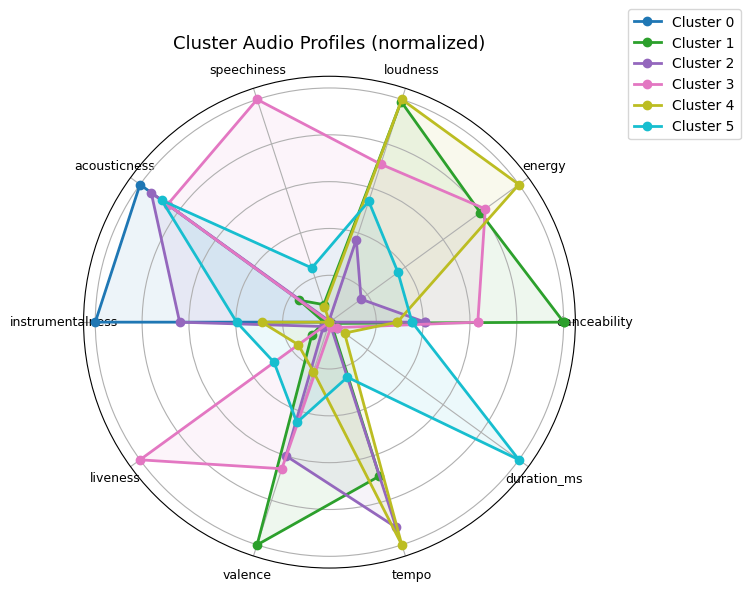

In [30]:
# Radar Chart — one polygon per cluster, each axis is a normalized audio feature
cp = cluster_profiles.toPandas()
features = audio_features

# Normalize each feature column to 0–1 (min-max) so all axes share the same scale
for f in features:
    col_min, col_max = cp[f].min(), cp[f].max()
    cp[f] = (cp[f] - col_min) / (col_max - col_min) if col_max != col_min else 0

# Build angles: evenly spaced around a full circle, then close the polygon
angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]  # repeat the first angle to close the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors_radar = plt.cm.tab10(np.linspace(0, 1, len(cp)))
for i, (_, row) in enumerate(cp.iterrows()):
    values = [row[f] for f in features] + [row[features[0]]]  # close the polygon
    ax.plot(angles, values, "o-", linewidth=2,
            color=colors_radar[i], label=f"Cluster {int(row['prediction'])}")
    ax.fill(angles, values, alpha=0.08, color=colors_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=9)
ax.set_yticklabels([])
ax.set_title("Cluster Audio Profiles (normalized)", size=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.show()

### Genre Map — All 114 Genres

Now we zoom out. Using the **full dataset** (`df_full`, all 114 genres), compute the mean audio profile per genre and run t-SNE on just 114 points. Each dot is a genre. Genres that sound similar land next to each other.

We exclude `duration_ms` — it describes track length, not what the music *sounds like*.

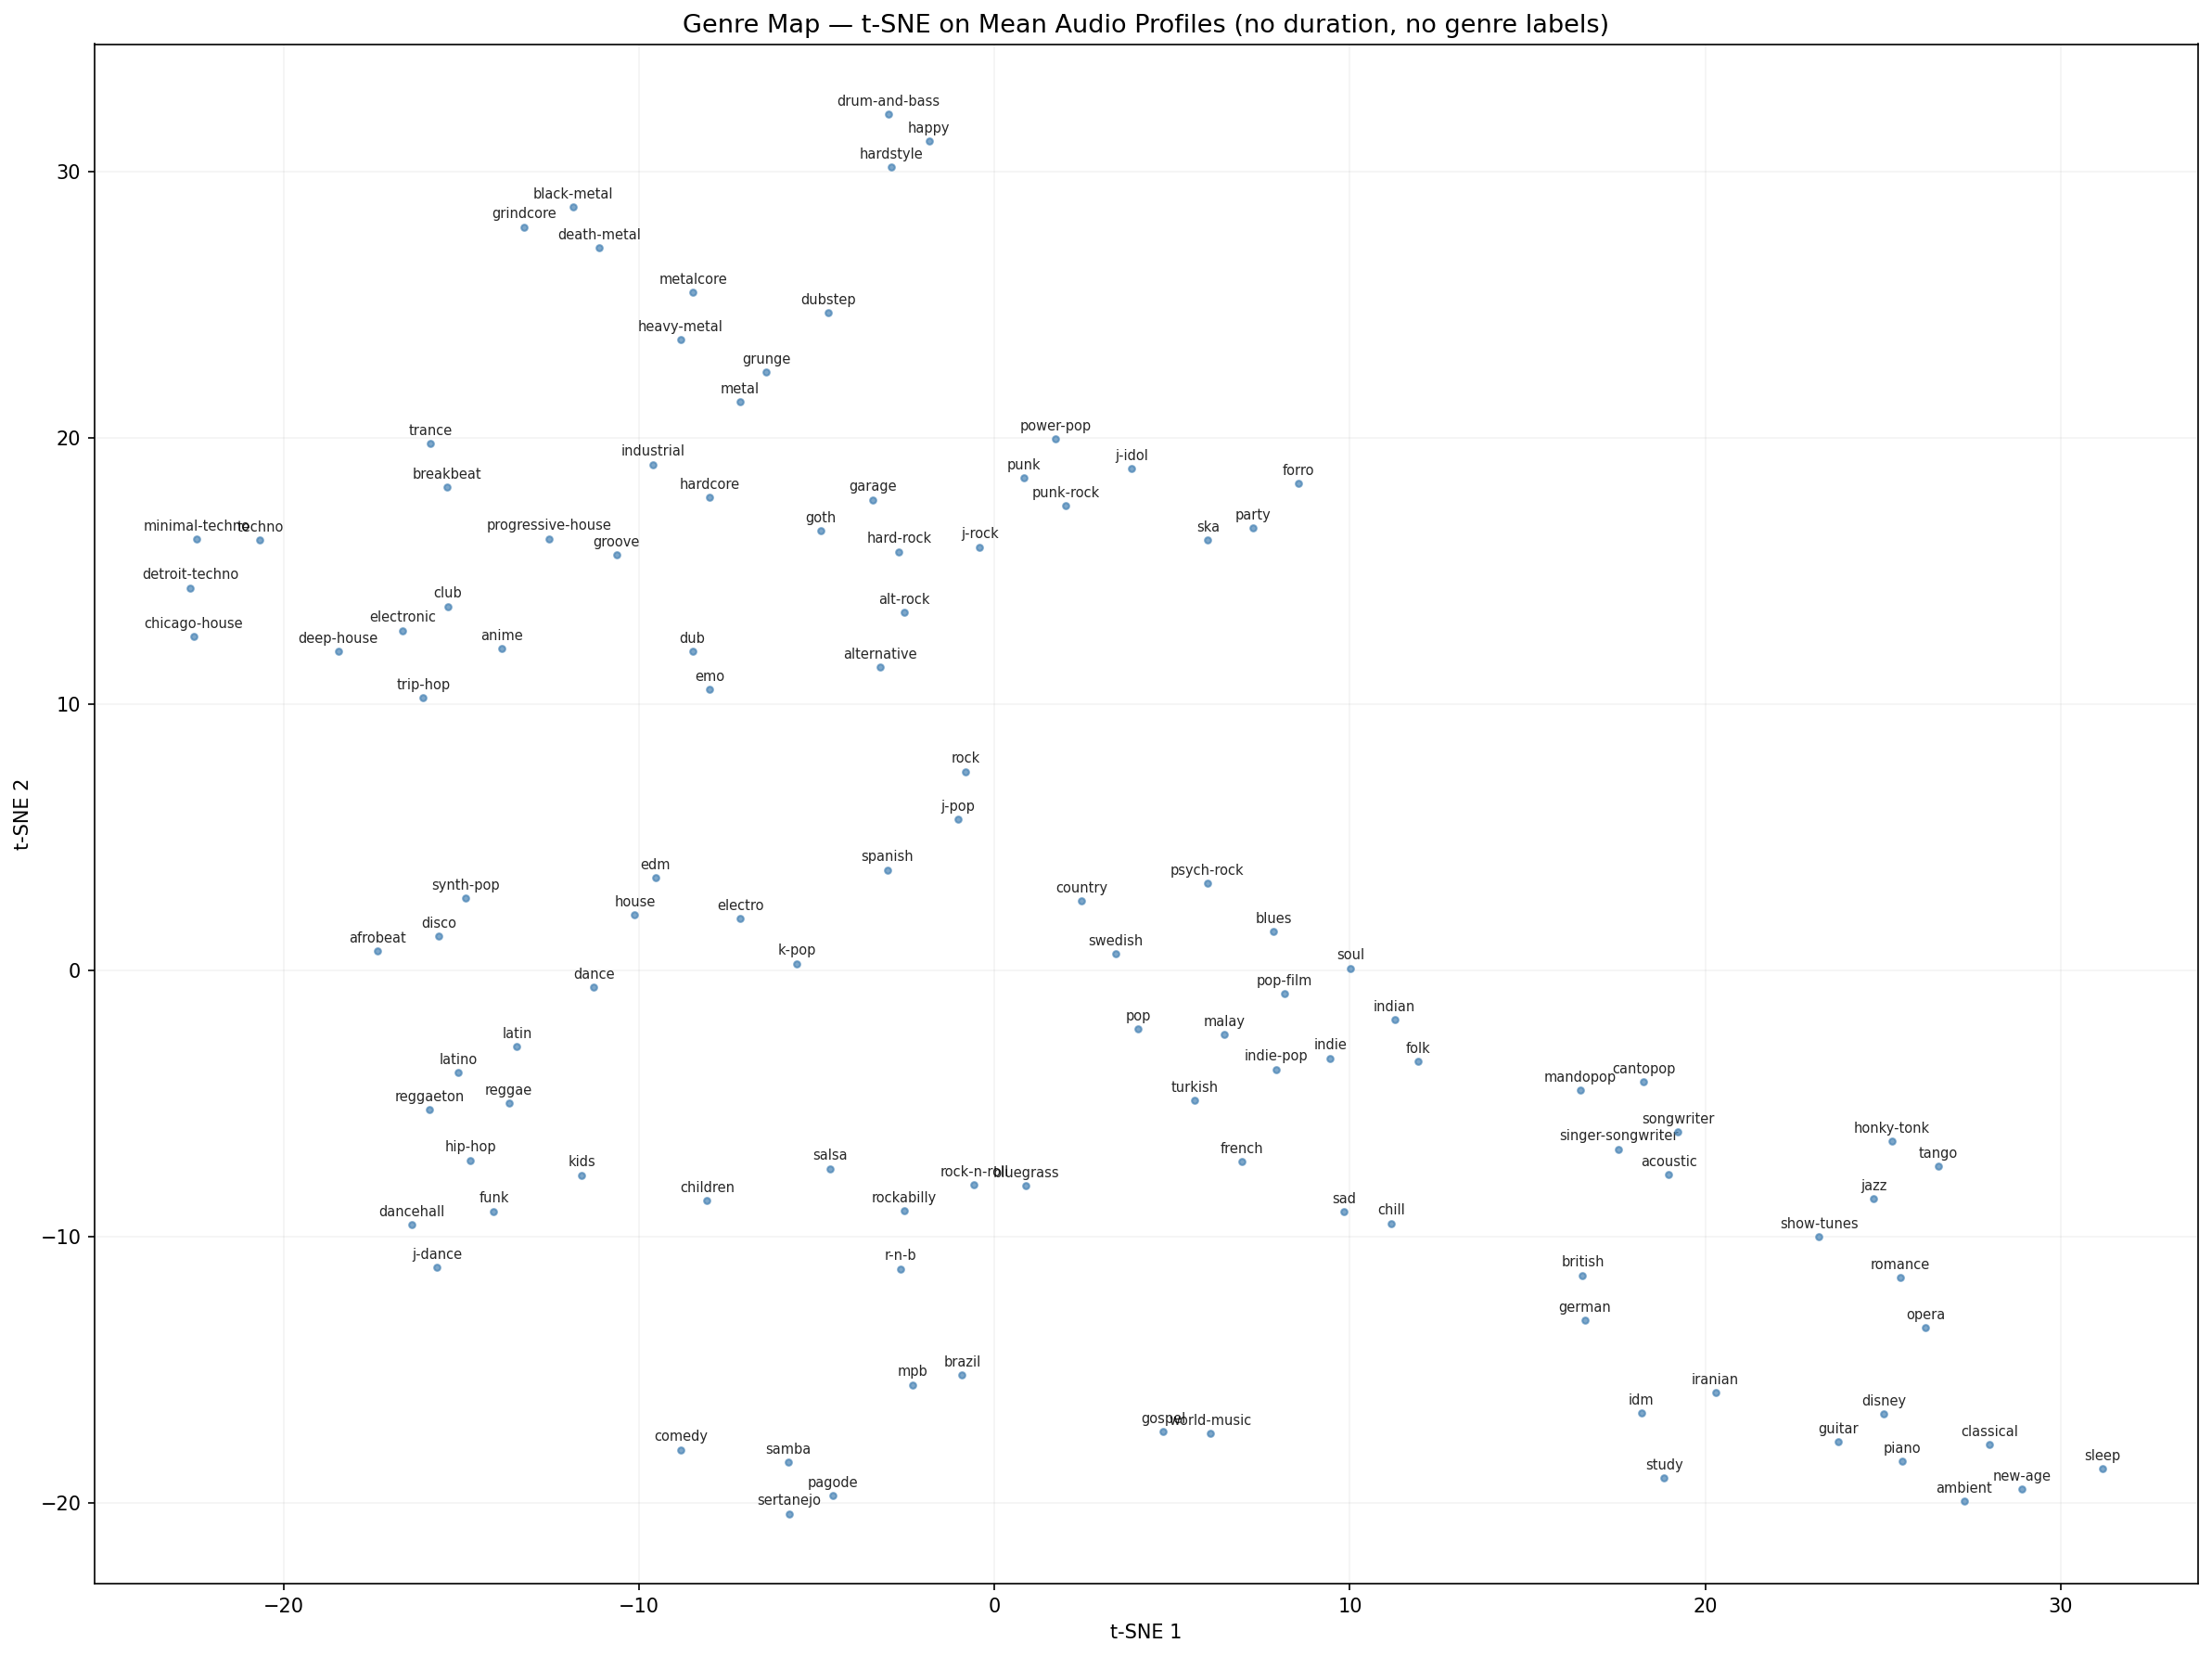

In [31]:
# Genre-level t-SNE map — using df_full (all 114 genres)
from sklearn.preprocessing import StandardScaler as SkScaler

sound_features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo"
]

# Compute mean audio profile per genre from FULL dataset
genre_profiles = df_full.groupBy("track_genre").agg(
    *[F.avg(f).alias(f) for f in sound_features]
).toPandas()

# Standardize
X_genres = SkScaler().fit_transform(genre_profiles[sound_features].values)

# t-SNE on 114 points — instant
tsne_genres = TSNE(n_components=2, random_state=42, perplexity=10, max_iter=1000)
genre_2d = tsne_genres.fit_transform(X_genres)

# Plot with labels
fig, ax = plt.subplots(figsize=(16, 12), dpi=150)
ax.scatter(genre_2d[:, 0], genre_2d[:, 1], s=10, alpha=0.7, c="steelblue", zorder=5)

for i, genre in enumerate(genre_profiles["track_genre"]):
    ax.annotate(genre, (genre_2d[i, 0], genre_2d[i, 1]),
                fontsize=7, alpha=0.85, ha="center", va="bottom",
                textcoords="offset points", xytext=(0, 3))

ax.set_title("Genre Map — t-SNE on Mean Audio Profiles (no duration, no genre labels)", fontsize=13)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

## Part 8: Discussion Questions

Answer these in a markdown cell below:

1. **Scaling:** What would happen if you ran PCA and K-Means on the raw (unscaled) features? Which features would dominate and why?

2. **PCA before K-Means:** Why did we apply PCA before K-Means instead of clustering on all 10 features? Connect this to the curse of dimensionality from the reading.

3. **Clusters vs. genres:** Do your clusters correspond to genres? If not, what does this suggest — are the clusters wrong, or is the genre labeling noisy?

4. **t-SNE vs. PCA:** The t-SNE plot likely shows more separation between groups than a 2D PCA scatter would. Why can t-SNE reveal structure that PCA misses? Why can't you use t-SNE output as input to K-Means?

## Part 8: Discussion Answers

**1. Scaling — what happens without it?**

`tempo` (~60–200 BPM) and `duration_ms` (~50,000–500,000 ms) have much larger numeric ranges than the 0–1 features like `danceability` or `energy`. Distance-based methods like K-Means compute Euclidean distance, so a 1-unit difference in `duration_ms` counts far more than a 1-unit difference in `danceability`. Without `StandardScaler`, K-Means would essentially cluster by *how long tracks are*, ignoring the subtle tonal features. `StandardScaler` (mean=0, std=1) puts every feature on equal footing before any distance is measured.

**2. Why PCA before K-Means?**

The *curse of dimensionality* says that in high-dimensional spaces, all points become roughly equidistant from each other — distance loses its discriminating power. With 10 features, many of them correlated (energy ↔ loudness, energy ↔ acousticness), we have redundant dimensions that add noise without signal. PCA compresses those correlated features into a few orthogonal components, removing noise and making K-Means distances more meaningful. It also speeds up training and makes the result more stable.

**3. Clusters vs. genres — are the clusters wrong?**

Not necessarily. K-Means clusters by *audio similarity* — it has never seen the word "genre". If a cluster mixes hip-hop and R&B, that's because those genres genuinely sound similar on the 10 audio features. Genre labels are socially and historically defined; they group music by culture, era, and marketing, not purely by sound. High cluster purity for genres like *classical* or *death-metal* (acoustically extreme) shows the method works. Overlap in genres like *pop/dance/EDM* reveals that the genre taxonomy itself is noisy from an audio standpoint.

**4. t-SNE vs. PCA — why can't you cluster on t-SNE output?**

PCA is a *linear* projection — it finds new axes that maximize variance but assumes the structure is linear. t-SNE is *non-linear*: it models probability distributions over pairwise distances and arranges points so that similar points stay close in 2D. This lets it reveal tight clusters and curved manifolds that PCA flattens out.

However, t-SNE **distorts global distances** — the distance between two clusters in t-SNE space is meaningless; only neighborhood structure is preserved. Running K-Means on t-SNE output would cluster on arbitrary 2D positions that don't reflect true high-dimensional proximity. t-SNE is a visualization lens, not a feature transformation.

In [32]:
spark.stop()